# Asistente inteligente con LLM y RAG para apoyo al diagnóstico FTTH

**Evaluación Parcial N°1 – ISY0101 Ingeniería de Soluciones con Inteligencia Artificial**

**Estudiante:** Miguel Zavala Vásquez

## Objetivo

Desarrollar un prototipo RAG que recupere antecedentes históricos de incidencias FTTH y documentación técnica externa para entregar una orientación técnica trazable ante una nueva incidencia.

> El prototipo funciona como apoyo al análisis. La validación, el diagnóstico y la decisión final corresponden al personal técnico.


## 1. Carga y exploración de la base histórica

Se utiliza una base anonimizada de incidencias FTTH. Primero se carga la información y se revisan las columnas y los motivos de falla disponibles.


In [1]:
import pandas as pd

archivo = "/EP1_FTTH_Base_Trabajo_Inicial (2).xlsx"

df = pd.read_excel(
    archivo,
    sheet_name="FTTH_Base_Trabajo"
)

print("Base FTTH cargada correctamente")
print("Cantidad de registros:", len(df))
print("Cantidad de columnas:", len(df.columns))

df.head()

Base FTTH cargada correctamente
Cantidad de registros: 1411
Cantidad de columnas: 14


,Caso_ID,Fecha Asignación,Estado,ETR (horas),Tipo Red,Afectación,Motivo del corte,Distancia,Fecha Medición,Comuna,Fecha Validación,Acción Reparación,Materiales Ocupados,Zona
0,FTTH-0001,"07-09-2026, 9:30:00 a. m.",CERRADA,1,FTTH,No,No existe corte,0.0,"07-09-2026, 11:00:00 a. m.",Lo Espejo,"07-09-2026, 12:00:00 p. m.",- Directora de establecimiento nos comenta que...,No,RM
1,FTTH-0002,"07-09-2026, 9:30:00 a. m.",CERRADA,1,FTTH,No,No existe corte,1.0,"07-09-2026, 1:15:00 p. m.",Huechuraba,"07-09-2026, 2:00:00 p. m.",- Se realiza medicion de NAP y esta se encuent...,No,RM
2,FTTH-0003,"06-09-2026, 9:00:00 a. m.",CERRADA,2,FTTH,No,No existe corte,1.0,"06-09-2026, 9:15:00 a. m.",El Monte,"06-09-2026, 12:00:00 p. m.",- Se realizará cambio de Cassette.\n- Se cambi...,Sí,RM
3,FTTH-0004,"05-09-2026, 9:15:00 a. m.",CERRADA,1,FTTH,No,No existe corte,0.0,"05-09-2026, 9:30:00 a. m.",Pirque,"05-09-2026, 11:00:00 a. m.",- Se llega a la dirección del cliente y la más...,Sí,RM
4,FTTH-0005,"04-09-2026, 1:00:00 p. m.",CERRADA,3,FTTH,No,Carga Alta,0.0,"05-09-2026, 9:00:00 a. m.",San Bernardo,"05-09-2026, 1:15:00 p. m.",- Moviles desplazando al punto del corte.\n- S...,Sí,RM


In [2]:
print("COLUMNAS DISPONIBLES:")
print(df.columns.tolist())

print("\nTIPOS DE FALLA MÁS FRECUENTES:")
print(df["Motivo del corte"].value_counts().head(15))

COLUMNAS DISPONIBLES:
['Caso_ID', 'Fecha Asignación', 'Estado', 'ETR (horas)', 'Tipo Red', 'Afectación', 'Motivo del corte', 'Distancia', 'Fecha Medición', 'Comuna', 'Fecha Validación', 'Acción Reparación', 'Materiales Ocupados', 'Zona']

TIPOS DE FALLA MÁS FRECUENTES:
Motivo del corte
No existe corte              711
Filamento cortado            180
Atenuación                   167
Caja CTO en mal estado        83
Filamento Atenuado            75
Carga Alta                    65
Corte interior de cliente     27
Descarga eléctrica            20
Trabajos viales               18
Vandalismo                    17
Poda                          10
Mufa Mal Estado                9
Equipos sin Energía            7
Accidente automovilístico      6
Incendio                       5
Name: count, dtype: int64


## 2. Selección de casos para el prototipo

Se seleccionan cuatro categorías relacionadas con fallas de interés operacional: **Atenuación, Filamento Atenuado, Filamento cortado y Caja CTO en mal estado**.

La base contiene 505 casos pertenecientes a estas cuatro categorías.


In [3]:
# Seleccionamos algunos casos con fallas útiles para nuestro prototipo
categorias_prototipo = [
    "Atenuación",
    "Filamento Atenuado",
    "Filamento cortado",
    "Caja CTO en mal estado"
]

df_prototipo = df[
    df["Motivo del corte"].isin(categorias_prototipo)
].copy()

print("Casos disponibles para el prototipo:", len(df_prototipo))

print("\nCantidad por categoría:")
print(df_prototipo["Motivo del corte"].value_counts())

Casos disponibles para el prototipo: 505

Cantidad por categoría:
Motivo del corte
Filamento cortado         180
Atenuación                167
Caja CTO en mal estado     83
Filamento Atenuado         75
Name: count, dtype: int64


In [4]:
columnas_revision = [
    "Caso_ID",
    "Motivo del corte",
    "Distancia",
    "Acción Reparación",
    "Materiales Ocupados"
]

for categoria in categorias_prototipo:
    print("\n" + "=" * 80)
    print("CATEGORÍA:", categoria)
    print("=" * 80)

    ejemplo = df_prototipo[
        df_prototipo["Motivo del corte"] == categoria
    ][columnas_revision].head(3)

    display(ejemplo)


CATEGORÍA: Atenuación


,Caso_ID,Motivo del corte,Distancia,Acción Reparación,Materiales Ocupados
9,FTTH-0010,Atenuación,637.0,Se repara atenuacion en mufa,Sí
21,FTTH-0022,Atenuación,1200.0,- Se mide la CTO 09 que es la más cercana al c...,Sí
25,FTTH-0026,Atenuación,1.0,SE REPARA FILAMENTO ATENUADO EN CTO,Sí



CATEGORÍA: Filamento Atenuado


,Caso_ID,Motivo del corte,Distancia,Acción Reparación,Materiales Ocupados
15,FTTH-0016,Filamento Atenuado,5000.0,Se realizan pruebas en mufa de emergencia M#7....,No
40,FTTH-0041,Filamento Atenuado,159.0,Se mide CTO 8 OSOCIADA A LT6 PON 3\nSE MIDE D...,Sí
44,FTTH-0045,Filamento Atenuado,159.0,Se corta FILAMENTO alimentador mostrando at. D...,Sí



CATEGORÍA: Filamento cortado


,Caso_ID,Motivo del corte,Distancia,Acción Reparación,Materiales Ocupados
5,FTTH-0006,Filamento cortado,3730.0,Se reparan 3 atenuaciones en ruta,Sí
32,FTTH-0033,Filamento cortado,13566.0,Se repara filamento en mufa M#7.504.918,Sí
35,FTTH-0036,Filamento cortado,0.0,Se tendera f.o 12 60mts. Por camara y realizar...,Sí



CATEGORÍA: Caja CTO en mal estado


,Caso_ID,Motivo del corte,Distancia,Acción Reparación,Materiales Ocupados
27,FTTH-0028,Caja CTO en mal estado,1.0,Se reparan 2 filamentos en CTO,Sí
30,FTTH-0031,Caja CTO en mal estado,1.0,Se reempalman los 2 pigtail de la CTO,Sí
82,FTTH-0083,Caja CTO en mal estado,189.0,Se tendera f.o 12 60mts. Por camara y realizar...,Sí


In [5]:
caso = df[df["Caso_ID"] == "FTTH-0010"].iloc[0]

print("CASO HISTÓRICO FTTH-0010")
print("=" * 60)

print("Tipo de red:", caso["Tipo Red"])
print("Motivo registrado:", caso["Motivo del corte"])
print("Distancia:", caso["Distancia"])
print("Comuna:", caso["Comuna"])
print("ETR:", caso["ETR (horas)"], "horas")

print("\nACCIÓN DE REPARACIÓN:")
print(caso["Acción Reparación"])

print("\nMATERIALES OCUPADOS:")
print(caso["Materiales Ocupados"])

CASO HISTÓRICO FTTH-0010
Tipo de red: FTTH
Motivo registrado: Atenuación
Distancia: 637.0
Comuna: Santiago
ETR: 1 horas

ACCIÓN DE REPARACIÓN:
Se repara atenuacion en  mufa

MATERIALES OCUPADOS:
Sí


## 3. Preparación de documentos para RAG

Cada incidencia seleccionada se transforma en un documento de conocimiento que conserva el `Caso_ID`, tipo de red, motivo, distancia aproximada, acción de reparación y uso de materiales. Esto permite mantener trazabilidad sin utilizar datos personales.


In [6]:
def crear_documento_ftth(fila):
    texto = f"""
Caso histórico: {fila['Caso_ID']}
Tipo de red: {fila['Tipo Red']}
Motivo registrado: {fila['Motivo del corte']}
Distancia aproximada: {fila['Distancia']} metros
Acción de reparación realizada: {fila['Acción Reparación']}
Uso de materiales: {fila['Materiales Ocupados']}
"""
    return texto.strip()


df_prototipo["Documento_RAG"] = df_prototipo.apply(
    crear_documento_ftth,
    axis=1
)

print("DOCUMENTO PREPARADO PARA RAG")
print("=" * 60)
print(df_prototipo.iloc[0]["Documento_RAG"])

DOCUMENTO PREPARADO PARA RAG
Caso histórico: FTTH-0006
Tipo de red: FTTH
Motivo registrado: Filamento cortado
Distancia aproximada: 3730.0 metros
Acción de reparación realizada: Se reparan 3 atenuaciones en ruta
Uso de materiales: Sí


## 4. Preparación del entorno y modelo de embeddings

Se instalan las librerías necesarias y se configura `gemini-embedding-001`. La API key se obtiene desde **Secrets de Google Colab** y no queda escrita directamente en el notebook.


In [7]:
!pip install -qU langchain-google-genai langchain-chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/20

In [8]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma

print("Importación correcta")
print("GoogleGenerativeAIEmbeddings: OK")
print("Chroma: OK")

Importación correcta
GoogleGenerativeAIEmbeddings: OK
Chroma: OK


In [10]:
import os
from google.colab import userdata
from langchain_google_genai import GoogleGenerativeAIEmbeddings

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

print("Modelo de embeddings configurado correctamente")

Modelo de embeddings configurado correctamente


In [11]:
texto_prueba = """
Incidencia FTTH con atenuación óptica.
Se detecta degradación en el enlace y se requiere
revisión de empalmes y elementos de la ruta.
"""

vector_prueba = embeddings.embed_query(texto_prueba)

print("Embedding generado correctamente")
print("Cantidad de dimensiones:", len(vector_prueba))
print("Primeros 10 valores del vector:")
print(vector_prueba[:10])

Embedding generado correctamente
Cantidad de dimensiones: 3072
Primeros 10 valores del vector:
[-0.0023011921, 0.0077568097, -0.0061508734, -0.05848002, 0.014623247, -0.00051262026, -0.009537583, -0.010488425, 0.00020982888, 0.010253708]


In [12]:
import numpy as np
from numpy.linalg import norm

texto_a = "Incidencia FTTH con atenuación óptica y degradación del nivel de señal."

texto_b = "Enlace de fibra presenta pérdida de potencia óptica y se requiere revisar empalmes."

texto_c = "Caja CTO dañada físicamente y requiere reparación de su estructura."

vector_a = embeddings.embed_query(texto_a)
vector_b = embeddings.embed_query(texto_b)
vector_c = embeddings.embed_query(texto_c)

def similitud_coseno(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

sim_ab = similitud_coseno(vector_a, vector_b)
sim_ac = similitud_coseno(vector_a, vector_c)

print("SIMILITUD SEMÁNTICA")
print("=" * 50)
print(f"Atenuación vs pérdida óptica : {sim_ab:.4f}")
print(f"Atenuación vs CTO dañada     : {sim_ac:.4f}")

SIMILITUD SEMÁNTICA
Atenuación vs pérdida óptica : 0.7829
Atenuación vs CTO dañada     : 0.6064


## 5. Construcción de la base vectorial

Para mantener un MVP equilibrado se utilizan **80 casos históricos: 20 por cada categoría**. Los documentos se convierten en embeddings y se almacenan en **Chroma**, permitiendo búsquedas por similitud semántica.


In [13]:
muestras = []

for categoria in categorias_prototipo:
    casos_categoria = df_prototipo[
        df_prototipo["Motivo del corte"] == categoria
    ].head(20)

    muestras.append(casos_categoria)

df_rag = pd.concat(muestras, ignore_index=True)

print("BASE DE CONOCIMIENTO INICIAL")
print("=" * 50)
print("Total de documentos:", len(df_rag))

print("\nDistribución:")
print(df_rag["Motivo del corte"].value_counts())

BASE DE CONOCIMIENTO INICIAL
Total de documentos: 80

Distribución:
Motivo del corte
Atenuación                20
Filamento Atenuado        20
Filamento cortado         20
Caja CTO en mal estado    20
Name: count, dtype: int64


In [14]:
from langchain_chroma import Chroma

textos = df_rag["Documento_RAG"].tolist()

metadatos = []

for _, fila in df_rag.iterrows():
    metadatos.append({
        "caso_id": fila["Caso_ID"],
        "motivo": fila["Motivo del corte"]
    })

print("Documentos preparados:", len(textos))
print("Metadatos preparados:", len(metadatos))

Documentos preparados: 80
Metadatos preparados: 80


In [15]:
from langchain_chroma import Chroma

base_vectorial = Chroma.from_texts(
    texts=textos,
    embedding=embeddings,
    metadatas=metadatos,
    collection_name="incidencias_ftth"
)

print("BASE VECTORIAL CREADA CORRECTAMENTE")
print("=" * 50)
print("Documentos indexados:", base_vectorial._collection.count())

BASE VECTORIAL CREADA CORRECTAMENTE
Documentos indexados: 80


In [16]:
consulta = """
Enlace FTTH presenta degradación de potencia óptica.
Se sospecha una atenuación en la fibra y se requiere
revisar empalmes o mufas de la ruta.
"""

resultados = base_vectorial.similarity_search(
    consulta,
    k=3
)

print("CONSULTA DEL INCIDENTE")
print("=" * 60)
print(consulta)

print("\nCASOS HISTÓRICOS RECUPERADOS POR EL RAG")
print("=" * 60)

for i, documento in enumerate(resultados, start=1):
    print(f"\nRESULTADO {i}")
    print("Caso:", documento.metadata["caso_id"])
    print("Motivo:", documento.metadata["motivo"])
    print("-" * 40)
    print(documento.page_content)

CONSULTA DEL INCIDENTE

Enlace FTTH presenta degradación de potencia óptica.
Se sospecha una atenuación en la fibra y se requiere
revisar empalmes o mufas de la ruta.


CASOS HISTÓRICOS RECUPERADOS POR EL RAG

RESULTADO 1
Caso: FTTH-0062
Motivo: Atenuación
----------------------------------------
Caso histórico: FTTH-0062
Tipo de red: FTTH
Motivo registrado: Atenuación
Distancia aproximada: 1.0 metros
Acción de reparación realizada: - SE MIDEN AMBOS PUERTOS 
- SE INDICA REVISAR NAP CERCANA A DICHOS PUERTOS TENIENDO POTENCIA DE -20dB EN SALIDA A CLIENTES.
- SE REALIZAN PRUEBAS EN MUFA SPLITTER, NOC INDICA QUE PUERTO ESTABA ALARMADO
Uso de materiales: No

RESULTADO 2
Caso: FTTH-0356
Motivo: Filamento Atenuado
----------------------------------------
Caso histórico: FTTH-0356
Tipo de red: FTTH
Motivo registrado: Filamento Atenuado
Distancia aproximada: 200.0 metros
Acción de reparación realizada: - SE REVISAN FAT ASOCIADAS A DIRECCIÓN TENIENDO POTENCIA EN -25.12dB
- SE REALIZAN PRUEBAS EN

## 6. Configuración del LLM y prompt de control

Gemini genera la respuesta a partir del contexto recuperado. El prompt establece reglas para evitar afirmar causas no confirmadas, exigir trazabilidad y mantener la decisión final en el personal técnico.


In [17]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash"
)

print("LLM configurado correctamente")

LLM configurado correctamente


In [18]:
from langchain_core.prompts import ChatPromptTemplate

prompt_ftth = ChatPromptTemplate.from_template("""
Eres un asistente técnico de apoyo para el análisis de incidencias
en redes FTTH.

Debes analizar la nueva incidencia utilizando ÚNICAMENTE los casos
históricos recuperados que aparecen en el contexto.

REGLAS:
1. No inventes mediciones, causas, reparaciones ni antecedentes.
2. No afirmes que una causa está confirmada si los datos no lo permiten.
3. Identifica patrones observados en los casos históricos recuperados.
4. Propón verificaciones técnicas basadas solamente en esos antecedentes.
5. Indica los Caso_ID utilizados como respaldo.
6. La decisión final corresponde al personal técnico en terreno.

NUEVA INCIDENCIA:
{incidencia}

CASOS HISTÓRICOS RECUPERADOS:
{contexto}

Entrega la respuesta utilizando esta estructura:

ANÁLISIS:
Breve análisis de la incidencia.

CASOS SIMILARES:
Indica los Caso_ID recuperados y por qué son relevantes.

POSIBLE ORIENTACIÓN:
Indica qué condición podría estar relacionada, sin presentarla como
diagnóstico confirmado.

VERIFICACIONES SUGERIDAS:
Enumera las verificaciones que se podrían realizar según los antecedentes.

TRAZABILIDAD:
Indica explícitamente qué casos históricos respaldan la respuesta.
""")

print("Prompt FTTH creado correctamente")

Prompt FTTH creado correctamente


## 7. Prueba 1 – Degradación de potencia óptica

Se prueba una nueva incidencia FTTH con potencia aproximada de **-25 dBm**. El sistema recupera casos históricos semánticamente relacionados y los utiliza como contexto para generar una orientación.


In [19]:
# Nueva incidencia para probar el sistema RAG
nueva_incidencia = """
Incidencia en red FTTH.
Se detecta degradación de potencia óptica en un cliente.
La potencia medida se encuentra aproximadamente en -25 dBm.
Se requiere determinar qué verificaciones realizar antes de efectuar
una reparación.
"""

# 1. Recuperar los 3 casos históricos más similares
casos_recuperados = base_vectorial.similarity_search(
    nueva_incidencia,
    k=3
)

# 2. Construir el contexto para el LLM
contexto = "\n\n".join(
    [
        f"CASO {doc.metadata.get('caso_id')}\n{doc.page_content}"
        for doc in casos_recuperados
    ]
)

print("INCIDENCIA NUEVA")
print("=" * 60)
print(nueva_incidencia)

print("\nCASOS RECUPERADOS POR EL RAG")
print("=" * 60)

for i, doc in enumerate(casos_recuperados, 1):
    print(f"\nResultado {i}")
    print("Caso:", doc.metadata.get("caso_id"))
    print("Motivo:", doc.metadata.get("motivo"))

INCIDENCIA NUEVA

Incidencia en red FTTH.
Se detecta degradación de potencia óptica en un cliente.
La potencia medida se encuentra aproximadamente en -25 dBm.
Se requiere determinar qué verificaciones realizar antes de efectuar
una reparación.


CASOS RECUPERADOS POR EL RAG

Resultado 1
Caso: FTTH-0437
Motivo: Filamento Atenuado

Resultado 2
Caso: FTTH-0062
Motivo: Atenuación

Resultado 3
Caso: FTTH-0134
Motivo: Atenuación


In [20]:
# Construimos el prompt final utilizando la incidencia
# y los casos recuperados por el RAG

prompt_final = prompt_ftth.format(
    incidencia=nueva_incidencia,
    contexto=contexto
)

# Enviamos la información recuperada al modelo Gemini
respuesta = llm.invoke(prompt_final)

print("RESPUESTA DEL ASISTENTE RAG FTTH")
print("=" * 60)
print(respuesta.content)

RESPUESTA DEL ASISTENTE RAG FTTH
[{'type': 'text', 'text': 'ANÁLISIS:\nSe reporta un evento de degradación de potencia óptica en un cliente FTTH con un nivel medido de aproximadamente -25 dBm. En la revisión de los antecedentes históricos con sintomatología similar (degradación/atenuación de potencia en rangos parecidos), se observa un patrón donde la causa puede originarse tanto en puntos intermedios de distribución (CTO/NAP/Mufa splitter) como en el puerto de la OLT por atenuación o suciedad.\n\nCASOS SIMILARES:\n- **FTTH-0437**: Muestra alta relevancia directa al presentar una degradación de potencia idéntica en aproximadamente -25 dBm. Se constató mediante traza que la pérdida en fibra era mínima y que la degradación provenía desde el puerto de la OLT, requiriendo limpieza de puerto.\n- **FTTH-0062**: Relevante por registrar problemas de atenuación midiendo puertos en salida a clientes y mufa splitter, identificando mediante NOC un puerto alarmado.\n- **FTTH-0134**: Relevante para 

In [21]:
def obtener_texto_respuesta(respuesta):
    contenido = respuesta.content

    if isinstance(contenido, str):
        return contenido

    if isinstance(contenido, list):
        partes = []

        for elemento in contenido:
            if isinstance(elemento, dict):
                texto = elemento.get("text", "")
                if texto:
                    partes.append(texto)
            else:
                partes.append(str(elemento))

        return "\n".join(partes)

    return str(contenido)


respuesta_limpia = obtener_texto_respuesta(respuesta)

print("RESPUESTA FINAL DEL ASISTENTE RAG FTTH")
print("=" * 70)
print(respuesta_limpia)

RESPUESTA FINAL DEL ASISTENTE RAG FTTH
ANÁLISIS:
Se reporta un evento de degradación de potencia óptica en un cliente FTTH con un nivel medido de aproximadamente -25 dBm. En la revisión de los antecedentes históricos con sintomatología similar (degradación/atenuación de potencia en rangos parecidos), se observa un patrón donde la causa puede originarse tanto en puntos intermedios de distribución (CTO/NAP/Mufa splitter) como en el puerto de la OLT por atenuación o suciedad.

CASOS SIMILARES:
- **FTTH-0437**: Muestra alta relevancia directa al presentar una degradación de potencia idéntica en aproximadamente -25 dBm. Se constató mediante traza que la pérdida en fibra era mínima y que la degradación provenía desde el puerto de la OLT, requiriendo limpieza de puerto.
- **FTTH-0062**: Relevante por registrar problemas de atenuación midiendo puertos en salida a clientes y mufa splitter, identificando mediante NOC un puerto alarmado.
- **FTTH-0134**: Relevante para la verificación de niveles 

## 8. Prueba 2 – Caja CTO en mal estado

La segunda prueba evalúa si el sistema diferencia otro tipo de problema. Ante una consulta por daño físico en una CTO, el recuperador busca antecedentes históricos de características similares.


In [22]:
nueva_incidencia_2 = """
Incidencia en red FTTH.
Se detecta daño físico en una caja CTO.
La caja presenta deterioro y requiere revisión del estado
de los filamentos, pigtails y conexiones internas.
Se necesita determinar qué verificaciones realizar antes
de efectuar una reparación.
"""

# Recuperamos 3 casos históricos similares
casos_recuperados_2 = base_vectorial.similarity_search(
    nueva_incidencia_2,
    k=3
)

# Construimos el contexto
contexto_2 = "\n\n".join(
    [
        f"CASO {doc.metadata.get('caso_id')}\n{doc.page_content}"
        for doc in casos_recuperados_2
    ]
)

print("SEGUNDA INCIDENCIA DE PRUEBA")
print("=" * 60)
print(nueva_incidencia_2)

print("\nCASOS RECUPERADOS POR EL RAG")
print("=" * 60)

for i, doc in enumerate(casos_recuperados_2, 1):
    print(f"\nResultado {i}")
    print("Caso:", doc.metadata.get("caso_id"))
    print("Motivo:", doc.metadata.get("motivo"))

SEGUNDA INCIDENCIA DE PRUEBA

Incidencia en red FTTH.
Se detecta daño físico en una caja CTO.
La caja presenta deterioro y requiere revisión del estado
de los filamentos, pigtails y conexiones internas.
Se necesita determinar qué verificaciones realizar antes
de efectuar una reparación.


CASOS RECUPERADOS POR EL RAG

Resultado 1
Caso: FTTH-0084
Motivo: Caja CTO en mal estado

Resultado 2
Caso: FTTH-0405
Motivo: Caja CTO en mal estado

Resultado 3
Caso: FTTH-0391
Motivo: Caja CTO en mal estado


In [23]:
prompt_final_2 = prompt_ftth.format(
    incidencia=nueva_incidencia_2,
    contexto=contexto_2
)

respuesta_2 = llm.invoke(prompt_final_2)

respuesta_limpia_2 = obtener_texto_respuesta(respuesta_2)

print("RESPUESTA FINAL - PRUEBA CTO")
print("=" * 70)
print(respuesta_limpia_2)

RESPUESTA FINAL - PRUEBA CTO
ANÁLISIS:
La incidencia reporta un daño físico y deterioro en una caja CTO, indicando la necesidad de inspeccionar filamentos, pigtails y conexiones internas para determinar las verificaciones previas a su reparación.

CASOS SIMILARES:
- **FTTH-0084**: Relevante porque registra el motivo "Caja CTO en mal estado" y contempló revisiones en los cables, filamentos, buffers y pruebas para confirmar el PON asociado, así como la verificación final de potencias en la CTO.
- **FTTH-0405**: Relevante por abordar una "Caja CTO en mal estado" con deterioro físico (sin tapa, uso de huincha aisladora, conectores rotos y desconectados), requiriendo mediciones de potencia y detección de puertas degradadas.
- **FTTH-0391**: Relevante al presentar "Caja CTO en mal estado" con afectación en elementos internos, requiriendo la reparación específica del pigtail en el cassette.

POSIBLE ORIENTACIÓN:
Los casos históricos sugieren que el deterioro físico de una CTO puede estar vinc

## Fuente externa de conocimiento técnico FTTH / GPON

Además de los históricos internos, se incorpora una fuente técnica externa: **ITU-T G.984.1**, utilizada como referencia general de arquitectura GPON.


In [24]:
# Fuente externa oficial para complementar la base RAG
# Referencia: ITU-T G.984.1 - Gigabit-capable passive optical networks (GPON)

fuente_externa_gpon = """
FUENTE EXTERNA: ITU-T G.984.1

Las redes GPON corresponden a redes ópticas pasivas de acceso.

Una arquitectura GPON está compuesta generalmente por:
- OLT (Optical Line Termination).
- ONU u ONT (Optical Network Unit / Optical Network Termination).
- ODN (Optical Distribution Network), que interconecta la OLT con las ONU/ONT.

La red de distribución óptica es pasiva y permite una relación
de uno a muchos entre la OLT y las ONU/ONT.

En el análisis de una red óptica deben considerarse las características
de la infraestructura óptica y los elementos que forman parte de la ODN.

Referencia:
ITU-T Recommendation G.984.1
Gigabit-capable passive optical networks (GPON): General characteristics.
"""

print("FUENTE EXTERNA CARGADA")
print("=" * 60)
print(fuente_externa_gpon)

FUENTE EXTERNA CARGADA

FUENTE EXTERNA: ITU-T G.984.1

Las redes GPON corresponden a redes ópticas pasivas de acceso.

Una arquitectura GPON está compuesta generalmente por:
- OLT (Optical Line Termination).
- ONU u ONT (Optical Network Unit / Optical Network Termination).
- ODN (Optical Distribution Network), que interconecta la OLT con las ONU/ONT.

La red de distribución óptica es pasiva y permite una relación
de uno a muchos entre la OLT y las ONU/ONT.

En el análisis de una red óptica deben considerarse las características
de la infraestructura óptica y los elementos que forman parte de la ODN.

Referencia:
ITU-T Recommendation G.984.1
Gigabit-capable passive optical networks (GPON): General characteristics.



In [25]:
# Incorporamos la fuente externa a la base vectorial

base_vectorial.add_texts(
    texts=[fuente_externa_gpon],
    metadatas=[
        {
            "caso_id": "ITU-G984.1",
            "motivo": "Documentación técnica GPON",
            "tipo_fuente": "fuente_externa"
        }
    ]
)

print("FUENTE EXTERNA INCORPORADA AL RAG")
print("=" * 60)
print("Documento externo: ITU-T G.984.1")
print("Total de documentos indexados:", base_vectorial._collection.count())

FUENTE EXTERNA INCORPORADA AL RAG
Documento externo: ITU-T G.984.1
Total de documentos indexados: 81


In [26]:
consulta_externa = """
¿Cuáles son los principales elementos que componen
una arquitectura de red GPON?
"""

resultados_externos = base_vectorial.similarity_search(
    consulta_externa,
    k=3
)

print("PRUEBA DE RECUPERACIÓN DE FUENTE EXTERNA")
print("=" * 60)

for i, doc in enumerate(resultados_externos, 1):
    print(f"\nResultado {i}")
    print("ID:", doc.metadata.get("caso_id"))
    print("Motivo:", doc.metadata.get("motivo"))
    print("Tipo de fuente:", doc.metadata.get("tipo_fuente", "fuente_interna"))

PRUEBA DE RECUPERACIÓN DE FUENTE EXTERNA

Resultado 1
ID: ITU-G984.1
Motivo: Documentación técnica GPON
Tipo de fuente: fuente_externa

Resultado 2
ID: FTTH-0084
Motivo: Caja CTO en mal estado
Tipo de fuente: fuente_interna

Resultado 3
ID: FTTH-0104
Motivo: Caja CTO en mal estado
Tipo de fuente: fuente_interna


## 10. Diferenciación de fuentes mediante metadatos

Los documentos se identifican como `fuente_interna` o `fuente_externa`. Esto permite controlar la recuperación y comprobar de dónde proviene cada antecedente.


In [27]:
consulta_combinada = """
Incidencia FTTH con degradación de potencia óptica.
Se requiere orientar la revisión considerando tanto
casos históricos de reparación como elementos generales
de la arquitectura GPON involucrados en la red.
"""

resultados_combinados = base_vectorial.similarity_search(
    consulta_combinada,
    k=5
)

print("PRUEBA DE RECUPERACIÓN COMBINADA")
print("=" * 60)

for i, doc in enumerate(resultados_combinados, 1):
    print(f"\nResultado {i}")
    print("ID:", doc.metadata.get("caso_id"))
    print("Motivo:", doc.metadata.get("motivo"))
    print("Tipo de fuente:", doc.metadata.get("tipo_fuente", "fuente_interna"))

PRUEBA DE RECUPERACIÓN COMBINADA

Resultado 1
ID: FTTH-0356
Motivo: Filamento Atenuado
Tipo de fuente: fuente_interna

Resultado 2
ID: FTTH-0437
Motivo: Filamento Atenuado
Tipo de fuente: fuente_interna

Resultado 3
ID: FTTH-0113
Motivo: Atenuación
Tipo de fuente: fuente_interna

Resultado 4
ID: FTTH-0134
Motivo: Atenuación
Tipo de fuente: fuente_interna

Resultado 5
ID: FTTH-0062
Motivo: Atenuación
Tipo de fuente: fuente_interna


In [28]:
muestra_metadata = base_vectorial._collection.get(limit=3)

print("METADATOS REALES GUARDADOS EN CHROMA")
print("=" * 60)

for metadata in muestra_metadata["metadatas"]:
    print(metadata)

METADATOS REALES GUARDADOS EN CHROMA
{'caso_id': 'FTTH-0010', 'motivo': 'Atenuación'}
{'caso_id': 'FTTH-0022', 'motivo': 'Atenuación'}
{'motivo': 'Atenuación', 'caso_id': 'FTTH-0026'}


In [29]:
# Agregamos el metadato "tipo_fuente" a los casos históricos internos

datos_chroma = base_vectorial._collection.get()

ids_internos = []
metadatos_actualizados = []

for doc_id, metadata in zip(
    datos_chroma["ids"],
    datos_chroma["metadatas"]
):
    # Identificamos los casos históricos por su Caso_ID FTTH
    if metadata.get("caso_id", "").startswith("FTTH-"):

        nuevo_metadata = metadata.copy()
        nuevo_metadata["tipo_fuente"] = "fuente_interna"

        ids_internos.append(doc_id)
        metadatos_actualizados.append(nuevo_metadata)

# Actualizamos solamente los metadatos
base_vectorial._collection.update(
    ids=ids_internos,
    metadatas=metadatos_actualizados
)

print("METADATOS ACTUALIZADOS CORRECTAMENTE")
print("=" * 60)
print("Casos históricos actualizados:", len(ids_internos))

METADATOS ACTUALIZADOS CORRECTAMENTE
Casos históricos actualizados: 80


## 11. Recuperación combinada y respuesta final

Para la prueba final se recuperan **3 casos históricos internos y 1 documento técnico externo**. Ambos tipos de fuente se integran en el contexto enviado al LLM.


In [30]:
consulta_mixta = """
Incidencia FTTH con degradación de potencia óptica.
Se requiere orientar técnicamente la revisión de la red,
considerando antecedentes históricos y documentación técnica GPON.
"""

# Recuperación desde casos históricos internos
resultados_internos = base_vectorial.similarity_search(
    consulta_mixta,
    k=3,
    filter={"tipo_fuente": "fuente_interna"}
)

# Recuperación desde documentación técnica externa
resultados_externos = base_vectorial.similarity_search(
    consulta_mixta,
    k=1,
    filter={"tipo_fuente": "fuente_externa"}
)

print("RECUPERACIÓN RAG: FUENTES INTERNAS + EXTERNAS")
print("=" * 65)

print("\nFUENTES INTERNAS RECUPERADAS:")
for doc in resultados_internos:
    print(
        "-",
        doc.metadata.get("caso_id"),
        "|",
        doc.metadata.get("motivo"),
        "|",
        doc.metadata.get("tipo_fuente")
    )

print("\nFUENTE EXTERNA RECUPERADA:")
for doc in resultados_externos:
    print(
        "-",
        doc.metadata.get("caso_id"),
        "|",
        doc.metadata.get("motivo"),
        "|",
        doc.metadata.get("tipo_fuente")
    )

RECUPERACIÓN RAG: FUENTES INTERNAS + EXTERNAS

FUENTES INTERNAS RECUPERADAS:
- FTTH-0437 | Filamento Atenuado | fuente_interna
- FTTH-0134 | Atenuación | fuente_interna
- FTTH-0113 | Atenuación | fuente_interna

FUENTE EXTERNA RECUPERADA:
- ITU-G984.1 | Documentación técnica GPON | fuente_externa


In [31]:
# Construimos un contexto combinado: fuentes internas + fuente externa

contexto_interno = "\n\n".join(
    [
        f"FUENTE INTERNA - CASO {doc.metadata.get('caso_id')}\n{doc.page_content}"
        for doc in resultados_internos
    ]
)

contexto_externo = "\n\n".join(
    [
        f"FUENTE EXTERNA - {doc.metadata.get('caso_id')}\n{doc.page_content}"
        for doc in resultados_externos
    ]
)

contexto_combinado = contexto_interno + "\n\n" + contexto_externo

print("CONTEXTO COMBINADO PREPARADO")
print("=" * 65)
print("Fuentes internas:", len(resultados_internos))
print("Fuentes externas:", len(resultados_externos))
print("Total de documentos utilizados:",
      len(resultados_internos) + len(resultados_externos))

CONTEXTO COMBINADO PREPARADO
Fuentes internas: 3
Fuentes externas: 1
Total de documentos utilizados: 4


In [32]:
prompt_combinado = f"""
Eres un asistente de apoyo técnico para diagnóstico de incidencias
en redes FTTH.

Debes responder utilizando EXCLUSIVAMENTE la información contenida
en las fuentes recuperadas.

REGLAS:
1. No inventes mediciones, causas, reparaciones ni antecedentes.
2. Diferencia claramente los antecedentes históricos internos
   de la documentación técnica externa.
3. No presentes una posible causa como diagnóstico confirmado.
4. Propón verificaciones basadas solamente en las fuentes recuperadas.
5. Indica los Caso_ID utilizados como respaldo.
6. Si utilizas información externa, identifica la referencia ITU-G984.1.
7. La decisión final corresponde al personal técnico en terreno.

INCIDENCIA:
{consulta_mixta}

CONTEXTO RECUPERADO:
{contexto_combinado}

Entrega la respuesta utilizando esta estructura:

ANÁLISIS:
Breve análisis de la incidencia.

ANTECEDENTES INTERNOS:
Indica los casos históricos relevantes y qué aportan.

FUENTE EXTERNA:
Indica qué información aporta la documentación técnica externa.

POSIBLE ORIENTACIÓN:
Indica condiciones que podrían estar relacionadas, sin confirmarlas
como diagnóstico.

VERIFICACIONES SUGERIDAS:
Enumera verificaciones basadas en los antecedentes recuperados.

TRAZABILIDAD:
Identifica claramente las fuentes internas y externas utilizadas.
"""

respuesta_combinada = llm.invoke(prompt_combinado)

respuesta_combinada_limpia = obtener_texto_respuesta(
    respuesta_combinada
)

print("RESPUESTA FINAL RAG - FUENTES INTERNAS + EXTERNAS")
print("=" * 70)
print(respuesta_combinada_limpia)

RESPUESTA FINAL RAG - FUENTES INTERNAS + EXTERNAS
ANÁLISIS:
Se analiza una incidencia en red FTTH por degradación de potencia óptica. La evaluación requiere revisar los elementos pasivos de la red de distribución óptica y los puertos de interconexión en equipos centrales, considerando que la decisión final y el diagnóstico definitivo corresponden al personal técnico en terreno.

ANTECEDENTES INTERNOS:
- **Caso_ID: FTTH-0437**: Reportó "Filamento Atenuado" a una distancia aproximada de 150.0 metros. Se registraron potencias degradadas en AP (-25 dB) provenientes desde la OLT hacia el SP. Tras tomar una traza desde la NAP (que mostró 1 dB de pérdida a los 150 m), se determinó que la potencia venía degradada desde la OLT y se resolvió realizando una limpieza en el puerto de la OLT, logrando traza sin eventos considerables y parámetros óptimos.
- **Caso_ID: FTTH-0134**: Reportó "Atenuación" (distancia 0.0 m). Aporta como antecedente la realización de mediciones de potencia en CTO y Budi pa

## 12. Visualización de los datos

El siguiente gráfico se genera con Python y Matplotlib a partir de los datos del prototipo. Permite visualizar la cantidad de casos disponibles en cada una de las cuatro categorías seleccionadas.


CASOS FTTH POR CATEGORÍA
Motivo del corte
Filamento cortado         180
Atenuación                167
Caja CTO en mal estado     83
Filamento Atenuado         75
Name: count, dtype: int64


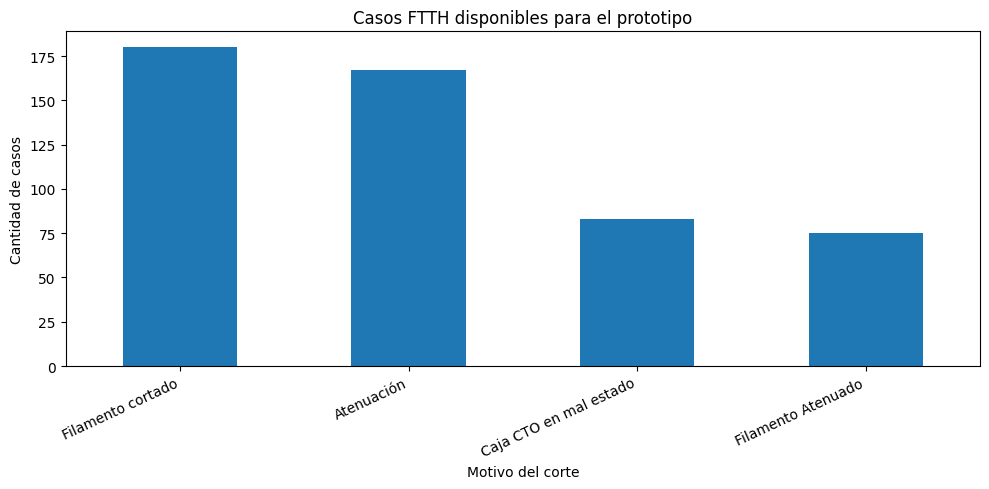

In [34]:
import matplotlib.pyplot as plt

# Contar los casos de cada categoría
cantidad_casos = (
    df_prototipo["Motivo del corte"]
    .value_counts()
    .sort_values(ascending=False)
)

# Mostrar los datos utilizados
print("CASOS FTTH POR CATEGORÍA")
print("=" * 40)
print(cantidad_casos)

# Crear gráfico
plt.figure(figsize=(10, 5))

cantidad_casos.plot(kind="bar")

plt.title("Casos FTTH disponibles para el prototipo")
plt.xlabel("Motivo del corte")
plt.ylabel("Cantidad de casos")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.show()

## 13. Alcance y limitaciones

- El MVP utiliza 80 casos históricos de los 505 disponibles en las cuatro categorías seleccionadas.
- La fuente externa incorporada corresponde a una síntesis técnica de ITU-T G.984.1.
- El prototipo no identifica automáticamente OLT, tarjeta, puerto, nodo, NAP, anillo o sitio técnico a partir de una dirección.
- El sistema no reemplaza mediciones OTDR, planimetría ni validación en terreno.
- La respuesta del LLM debe ser revisada por personal técnico.

### Proyección futura

Como evolución se podría integrar información de inventario y planta para asociar una dirección o servicio con su infraestructura FTTH antes de ejecutar la recuperación RAG.
